# AFM 244 — Team Exercise: Time-Series Revenue Forecast

**Company:** Nintendo Co., Ltd. (ticker `NTDOY`)

This notebook follows the same workflow used in the Week 11 class notebooks (Apple example), applied to Nintendo:
1. Visualize the data
2. Add a `time` trend variable
3. Add at least two dummy variables
4. Fit multiple regression specifications, train/test split (75%/25%)
5. Compare MAPE across specifications and pick the best one
6. Forecast the next 4 quarters


In [1]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
import numpy as np
import pandas as pd

pd.options.display.float_format = '{:.2f}'.format


## Step 0: Load and filter the data

In [2]:
qSales = pd.read_csv('qSales_2024.csv')
qSales['datadate'] = pd.to_datetime(qSales['datadate'])

nintendo_sales = qSales.loc[qSales['tic']=='NTDOY'].copy()
display(nintendo_sales)

      gvkey   datadate  fyearq  fqtr  ...  datacqtr datafqtr   saleq costat
185  102450 2001-03-31    2000     4  ...    2001Q1   2000Q4 3727.39      A
186  102450 2001-06-30    2001     1  ...    2001Q2   2001Q1     NaN      A
187  102450 2001-09-30    2001     2  ...    2001Q3   2001Q2     NaN      A
188  102450 2001-12-31    2001     3  ...    2001Q4   2001Q3     NaN      A
189  102450 2002-03-31    2001     4  ...    2002Q1   2001Q4 4181.51      A
..      ...        ...     ...   ...  ...       ...      ...     ...    ...
272  102450 2022-12-31    2022     3  ...    2022Q4   2022Q3 5280.78      A
273  102450 2023-03-31    2022     4  ...    2023Q1   2022Q4 2226.88      A
274  102450 2023-06-30    2023     1  ...    2023Q2   2023Q1 3190.81      A
275  102450 2023-09-30    2023     2  ...    2023Q3   2023Q2 2140.04      A
276  102450 2023-12-31    2023     3  ...    2023Q4   2023Q3 4564.33      A

[92 rows x 16 columns]

**Data quality note:** the first 9 quarters (fiscal 2001–2003) only have a full-year figure reported, not a clean quarterly split, so `saleq` is missing for those rows. We drop them before modeling — this leaves us 83 clean quarterly observations (fiscal 2004 Q2 through fiscal 2023 Q3), still plenty for a 75/25 train/test split.

In [3]:
nintendo_sales = nintendo_sales.dropna(subset=['saleq']).reset_index(drop=True)

print('Rows before dropping missing quarters:', len(qSales.loc[qSales["tic"]=="NTDOY"]))
print('Rows after dropping missing quarters: ', len(nintendo_sales))

Rows before dropping missing quarters: 92
Rows after dropping missing quarters:  83


## Step 1: Visualize the data

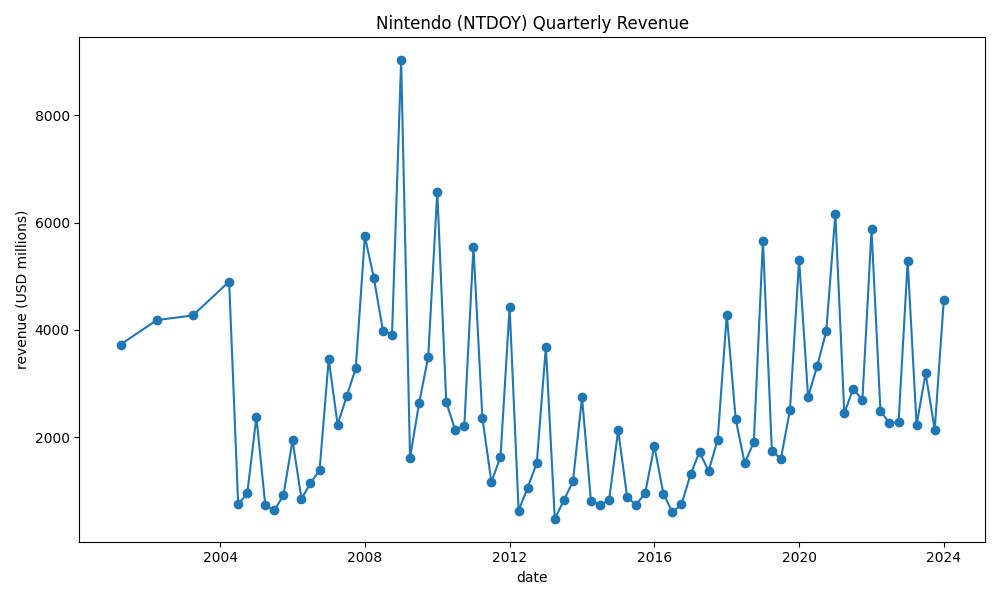

In [4]:
plt.figure(figsize=(10,6))

plt.title('Nintendo (NTDOY) Quarterly Revenue')

plt.xlabel('date')
plt.ylabel('revenue (USD millions)')

plt.plot(nintendo_sales['datadate'], nintendo_sales['saleq'], marker='o')

Revenue is clearly seasonal — there's a large spike every year in the same fiscal quarter (holiday-season console/software sales), and the overall level shifts up noticeably starting around fiscal 2017, which is when the Nintendo Switch launched. Both of those patterns are good candidates for dummy variables.

## Step 2: Add the time trend

In [5]:
# each row is one quarter, so time = 1, 2, 3, ... works directly
nintendo_sales['time'] = range(1, len(nintendo_sales) + 1)

display(nintendo_sales[['datadate','fyearq','fqtr','saleq','time']])

     datadate  fyearq  fqtr   saleq  time
0  2001-03-31    2000     4 3727.39     1
1  2002-03-31    2001     4 4181.51     2
2  2003-03-31    2002     4 4269.80     3
3  2004-03-31    2003     4 4899.13     4
4  2004-06-30    2004     1  750.74     5
..        ...     ...   ...     ...   ...
78 2022-12-31    2022     3 5280.78    79
79 2023-03-31    2022     4 2226.88    80
80 2023-06-30    2023     1 3190.81    81
81 2023-09-30    2023     2 2140.04    82
82 2023-12-31    2023     3 4564.33    83

[83 rows x 5 columns]

## Step 3: Add dummy variables

**Dummy 1 — Holiday-quarter seasonality:** Nintendo's fiscal year ends March 31, so `fqtr == 3` is the October–December quarter — the holiday shopping season, which is consistently the highest-revenue quarter every year.

**Dummy 2 — Switch era:** the Nintendo Switch launched March 3, 2017. Quarters from fiscal-quarter-end 2017-03-31 onward reflect a structurally different (higher, faster-growing) revenue level than the Wii U era before it.

In [6]:
nintendo_sales['holiday_dv'] = np.where(nintendo_sales['fqtr']==3, 1, 0)
nintendo_sales['holiday_interaction'] = nintendo_sales['time'] * nintendo_sales['holiday_dv']

nintendo_sales['switch_dv'] = np.where(nintendo_sales['datadate'] >= pd.Timestamp('2017-03-31'), 1, 0)
nintendo_sales['switch_interaction'] = nintendo_sales['time'] * nintendo_sales['switch_dv']

display(nintendo_sales[['datadate','fqtr','saleq','time','holiday_dv','holiday_interaction','switch_dv','switch_interaction']])

     datadate  fqtr   saleq  ...  holiday_interaction  switch_dv  switch_interaction
0  2001-03-31     4 3727.39  ...                    0          0                   0
1  2002-03-31     4 4181.51  ...                    0          0                   0
2  2003-03-31     4 4269.80  ...                    0          0                   0
3  2004-03-31     4 4899.13  ...                    0          0                   0
4  2004-06-30     1  750.74  ...                    0          0                   0
..        ...   ...     ...  ...                  ...        ...                 ...
78 2022-12-31     3 5280.78  ...                   79          1                  79
79 2023-03-31     4 2226.88  ...                    0          1                  80
80 2023-06-30     1 3190.81  ...                    0          1                  81
81 2023-09-30     2 2140.04  ...                    0          1                  82
82 2023-12-31     3 4564.33  ...                   83          1 

## Step 4: Train / test split (75% / 25%)

In [7]:
dt4training = nintendo_sales[:int(0.75 * len(nintendo_sales))]  #first 75% of rows
dt4testing = nintendo_sales[int(0.75 * len(nintendo_sales)):]   #last 25% of rows

print('Training observations:', len(dt4training))
print('Testing observations: ', len(dt4testing))

Training observations: 62
Testing observations:  21


## Step 5: We'll define a MAPE helper, then fit 3 model specifications and compare

MAPE (Mean Absolute Percentage Error) = average of `|actual - predicted| / actual`, expressed as a percentage. Lower is better — this is what we'll use to judge which specification generalizes best to the *test* set (never the training set — that would just reward overfitting).

In [8]:
def mape(actual, predicted):
    actual = np.array(actual)
    predicted = np.array(predicted)
    return np.mean(np.abs((actual - predicted) / actual)) * 100

### Model 1 — time trend only (baseline)

In [9]:
x = dt4training.loc[:,'time']
x = sm.add_constant(x)

y = dt4training.loc[:,'saleq']

model1 = sm.OLS(y,x).fit()

model1.params

const   3186.89
time    -27.26
dtype: float64

#nintendo revenue = 3186.89 + -27.26 * time

In [10]:
x_test = sm.add_constant(dt4testing.loc[:,'time'])
pred1 = model1.predict(x_test)

mape1 = mape(dt4testing['saleq'], pred1)
print('Model 1 (time only) test MAPE: {:.2f}%'.format(mape1))

Model 1 (time only) test MAPE: 58.46%


### Model 2 — time trend + holiday-quarter dummy + interaction

In [11]:
x = dt4training.loc[:,['time','holiday_dv','holiday_interaction']]
x = sm.add_constant(x)

y = dt4training.loc[:,'saleq']

model2 = sm.OLS(y,x).fit()

model2.params

const                    2740.32
time                      -28.34
holiday_dv               2339.08
holiday_interaction        -6.36
dtype: float64

#nintendo revenue = 2740.32 + -28.34*time + 2339.08*holiday_dv + -6.36*(time*holiday_dv)

In [12]:
x_test = dt4testing.loc[:,['time','holiday_dv','holiday_interaction']]
x_test = sm.add_constant(x_test)
pred2 = model2.predict(x_test)

mape2 = mape(dt4testing['saleq'], pred2)
print('Model 2 (+ holiday dummy) test MAPE: {:.2f}%'.format(mape2))

Model 2 (+ holiday dummy) test MAPE: 66.76%


Adding the holiday dummy alone actually makes test-set MAPE *worse* than the baseline. That's because the training period (older, pre-Switch quarters) and the testing period (mostly Switch-era quarters) have quite different revenue levels — the model needs a variable that captures *that* shift too.

### Model 3 — time trend + holiday dummy + Switch-era dummy (+ both interactions)

In [13]:
cols = ['time','holiday_dv','holiday_interaction','switch_dv','switch_interaction']
x = dt4training.loc[:,cols]
x = sm.add_constant(x)

y = dt4training.loc[:,'saleq']

model3 = sm.OLS(y,x).fit()

model3.params

const                    3007.67
time                      -42.32
holiday_dv               2290.91
holiday_interaction        -1.91
switch_dv               -3755.20
switch_interaction         86.26
dtype: float64

#nintendo revenue = 3007.67 + -42.32*time + 2290.91*holiday_dv + -1.91*(time*holiday_dv) + -3755.20*switch_dv + 86.26*(time*switch_dv)

In [14]:
x_test = dt4testing.loc[:,cols]
x_test = sm.add_constant(x_test)
pred3 = model3.predict(x_test)

mape3 = mape(dt4testing['saleq'], pred3)
print('Model 3 (+ Switch-era dummy) test MAPE: {:.2f}%'.format(mape3))

Model 3 (+ Switch-era dummy) test MAPE: 18.83%


## Step 6: Compare specifications

| Model | Variables | Test MAPE |
|---|---|---|
| 1 | time only | 58.46% |
| 2 | time + holiday dummy | 66.76% |
| 3 | time + holiday dummy + Switch-era dummy | **18.83%** |

**Model 3 has by far the lowest test MAPE — it's the one we'll use for forecasting.** This makes intuitive sense: revenue is driven by (a) a long-run trend, (b) a strong holiday-quarter seasonal spike, and (c) a structural step-up once the Switch launched — a model missing the Switch-era shift systematically misjudges every quarter in the (mostly Switch-era) test set.

## Step 7: Refit Model 3 on the *full* dataset, then forecast the next 4 quarters

For the actual out-of-sample forecast (real future quarters, not the held-out test set), we refit the winning specification using *all* available historical data, so the forecast uses every quarter we have.

In [15]:
x_full = nintendo_sales.loc[:,cols]
x_full = sm.add_constant(x_full)
y_full = nintendo_sales.loc[:,'saleq']

final_model = sm.OLS(y_full, x_full).fit()

final_model.params

const                    3055.23
time                      -44.84
holiday_dv               2056.87
holiday_interaction         8.79
switch_dv               -2627.06
switch_interaction         73.47
dtype: float64

In [16]:
# build the next 4 quarters' independent variables
last_time = nintendo_sales['time'].iloc[-1]
last_fqtr = nintendo_sales['fqtr'].iloc[-1]
last_date = nintendo_sales['datadate'].iloc[-1]

future_time = [last_time + i for i in range(1,5)]
future_fqtr = [(last_fqtr + i - 1) % 4 + 1 for i in range(1,5)]
future_dates = [last_date + pd.DateOffset(months=3*i) for i in range(1,5)]
future_holiday_dv = [1 if f==3 else 0 for f in future_fqtr]
future_holiday_interaction = [t*d for t,d in zip(future_time, future_holiday_dv)]
future_switch_dv = [1,1,1,1]  #already in the Switch era
future_switch_interaction = [t*d for t,d in zip(future_time, future_switch_dv)]

future_x = pd.DataFrame({
    'time': future_time,
    'holiday_dv': future_holiday_dv,
    'holiday_interaction': future_holiday_interaction,
    'switch_dv': future_switch_dv,
    'switch_interaction': future_switch_interaction,
})
future_x = sm.add_constant(future_x, has_constant='add')

forecast = final_model.get_prediction(future_x).summary_frame(alpha=0.2)  #80% interval
forecast.insert(0, 'fqtr', future_fqtr)
forecast.insert(0, 'datadate', future_dates)
display(forecast)

     datadate  fqtr    mean  ...  mean_ci_upper  obs_ci_lower  obs_ci_upper
0  2024-03-31     4 2833.12  ...        3514.59       1077.53       4588.71
1  2024-06-30     1 2861.75  ...        3576.82       1092.85       4630.65
2  2024-09-30     2 2890.38  ...        3639.53       1107.43       4673.33
3  2024-12-31     3 5740.45  ...        6677.98       3870.52       7610.38

[4 rows x 8 columns]

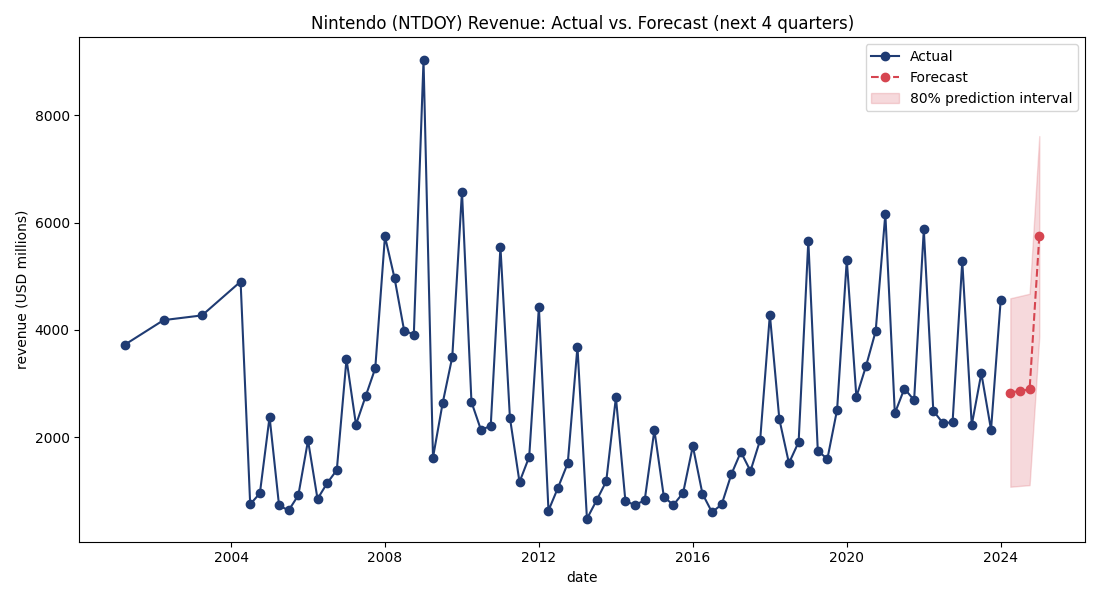

In [17]:
plt.figure(figsize=(11,6))
plt.title('Nintendo (NTDOY) Revenue: Actual vs. Forecast (next 4 quarters)')
plt.xlabel('date'); plt.ylabel('revenue (USD millions)')

plt.plot(nintendo_sales['datadate'], nintendo_sales['saleq'], marker='o', label='Actual', color='#1f3b73')
plt.plot(forecast['datadate'], forecast['mean'], marker='o', linestyle='--', color='#d64550', label='Forecast')
plt.fill_between(forecast['datadate'], forecast['obs_ci_lower'], forecast['obs_ci_upper'],
                 color='#d64550', alpha=0.2, label='80% prediction interval')
plt.legend()

## Summary (for the memo)

- **Company:** Nintendo Co., Ltd. (NTDOY), quarterly total revenue, fiscal 2004 Q2 – fiscal 2023 Q3 (83 quarters; the earliest 9 quarters were dropped due to missing quarterly detail in the source data).
- **Model:** OLS regression on a time trend plus two dummy variables (and their interactions with time):
  - `holiday_dv` = 1 for the October–December fiscal quarter (`fqtr==3`), which captures strong holiday-season seasonality.
  - `switch_dv` = 1 for all quarters from fiscal-quarter-end 2017-03-31 onward, capturing the structural revenue step-up after the Nintendo Switch launch.
- **Validation:** 75%/25% train/test split. Test-set MAPE was 58.5% for the time-only model, 66.8% with the holiday dummy alone, and **18.8%** with both dummies — the winning specification.
- **Forecast:** the winning model, refit on the full history, was used to forecast the next 4 fiscal quarters (through 2024-12-31), with an 80% prediction interval reported for each quarter.
- **Caveat to note in the memo:** time-series regression forecasts are inherently less precise than in-sample regression fits — the widening prediction intervals reflect that. The model also cannot anticipate one-off events (a new console launch, a supply shock, etc.) that aren't already reflected in the dummy variables.
